In [ ]:
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from zimtohrli import mos_from_signals
from frechet_audio_distance import FrechetAudioDistance


In [ ]:
ORIGINAL_DIR_PATH = ""
GENERATED_GRIFFIN_LIM_DIR_PATH = ""
GENERATED_WAVERNN_FROM_SCRATCH_DIR_PATH = ""
GENERATED_WAVERNN_FINE_TUNING_DIR_PATH = ""
GENERATED_WAVERNN_LJSPEECH_DIR_PATH = ""
GENERATED_HIFIGAN_FROM_SCRATCH_DIR_PATH = ""
GENERATED_HIFIGAN_FINE_TUNING_DIR_PATH = ""
GENERATED_HIFIGAN_LJSPEECH_DIR_PATH = ""

# funkcje do analizy

## cechy

In [3]:
FRAME_LENGTH = 1024
HOP_LENGTH = 512

### Zero-crossing rate

In [ ]:
def calculate_zcr_delta(original_dir_path, generated_dir_path):
    """ Oblicza średnią różnicę w ZCR dla poszczególnych klas """
    classes = os.listdir(original_dir_path)
    assert classes == os.listdir(generated_dir_path), "classes are not equal"
    results_all = []
    results_classes = []
    for c in classes:
        class_results = []
        for f in os.listdir(os.path.join(original_dir_path, c)):
            original_file_path = os.path.join(original_dir_path, c, f)
            generated_file_path = os.path.join(generated_dir_path, c, f)
            assert os.path.isfile(generated_file_path), "missing file"
            signal_a, _ = librosa.load(original_file_path, mono=True)
            signal_b, _ = librosa.load(generated_file_path, mono=True)
            zcr_original = np.mean(librosa.feature.zero_crossing_rate(y=signal_a, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0])            
            zcr_generated = np.mean(librosa.feature.zero_crossing_rate(y=signal_b, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0])
            zcr_delta = zcr_original - zcr_generated
            class_results.append(zcr_delta)
            results_all.append(zcr_delta)
        results_classes.append(round(np.mean(class_results), 2))
    print(*classes, sep=", ")
    print(*results_classes, sep=", ")
    print(f"mean zcr delta = {round(np.mean(results_all), 2)}")

In [73]:
print("Griffin-Lim")
calculate_zcr_delta(ORIGINAL_DIR_PATH, GENERATED_GRIFFIN_LIM_DIR_PATH)
print("WaveRNN from scratch")
calculate_zcr_delta(ORIGINAL_DIR_PATH, GENERATED_WAVERNN_FROM_SCRATCH_DIR_PATH)
print("WaveRNN fine-tuning")
calculate_zcr_delta(ORIGINAL_DIR_PATH, GENERATED_WAVERNN_FINE_TUNING_DIR_PATH)
print("WaveRNN LJ Speech")
calculate_zcr_delta(ORIGINAL_DIR_PATH, GENERATED_WAVERNN_LJSPEECH_DIR_PATH)
print("HiFi-GAN from scratch")
calculate_zcr_delta(ORIGINAL_DIR_PATH, GENERATED_HIFIGAN_FROM_SCRATCH_DIR_PATH)
print("HiFi-GAN fine-tuning")
calculate_zcr_delta(ORIGINAL_DIR_PATH, GENERATED_HIFIGAN_FINE_TUNING_DIR_PATH)
print("HiFi-GAN LJ Speech")
calculate_zcr_delta(ORIGINAL_DIR_PATH, GENERATED_HIFIGAN_LJSPEECH_DIR_PATH)

Griffin-Lim
airplane, breathing, brushing_teeth, can_opening, car_horn, cat, chainsaw, chirping_birds, church_bells, clapping, clock_alarm, clock_tick, coughing, cow, crackling_fire, crickets, crow, crying_baby, dog, door_wood_creaks, door_wood_knock, drinking_sipping, engine, fireworks, footsteps, frog, glass_breaking, hand_saw, helicopter, hen, insects, keyboard_typing, laughing, mouse_click, pig, pouring_water, rain, rooster, sea_waves, sheep, siren, sneezing, snoring, thunderstorm, toilet_flush, train, vacuum_cleaner, washing_machine, water_drops, wind
-0.02, -0.02, -0.04, -0.05, -0.03, -0.03, -0.02, -0.05, -0.02, -0.03, 0.05, -0.01, -0.02, -0.01, -0.02, 0.12, -0.05, -0.04, -0.01, -0.05, -0.01, -0.02, -0.02, -0.02, -0.02, -0.04, -0.03, -0.03, 0.0, -0.03, -0.02, -0.03, -0.02, -0.01, -0.02, -0.05, -0.05, -0.04, -0.02, -0.03, -0.01, -0.02, -0.02, -0.01, -0.04, -0.01, -0.06, -0.04, -0.02, -0.02
mean zcr delta = -0.02
WaveRNN from scratch
airplane, breathing, brushing_teeth, can_opening

### Spectral centroid

In [ ]:
def calculate_spectral_centroid_delta(original_dir_path, generated_dir_path):
    """ Oblicza średnią różnicę w spectral centroid dla dla poszczególnych klas """
    classes = os.listdir(original_dir_path)
    assert classes == os.listdir(generated_dir_path), "classes are not equal"
    results_all = []
    results_classes = []
    for c in classes:
        class_results = []
        for f in os.listdir(os.path.join(original_dir_path, c)):
            original_file_path = os.path.join(original_dir_path, c, f)
            generated_file_path = os.path.join(generated_dir_path, c, f)
            assert os.path.isfile(generated_file_path), "missing file"
            signal_a, sr_a = librosa.load(original_file_path, mono=True)
            signal_b, sr_b = librosa.load(generated_file_path, mono=True)
            sc_original = np.mean(librosa.feature.spectral_centroid(y=signal_a, sr=sr_a, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)[0])
            sc_generated = np.mean(librosa.feature.spectral_centroid(y=signal_b, sr=sr_b, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)[0])
            sc_delta = sc_original - sc_generated
            class_results.append(sc_delta)
            results_all.append(sc_delta)
        results_classes.append(round(np.mean(class_results), 2))
    print(*classes, sep=", ")
    print(*results_classes, sep=", ")
    print(f"mean spectral centroid delta [Hz] = {round(np.mean(results_all), 2)}")

In [79]:
print("Griffin-Lim")
calculate_spectral_centroid_delta(ORIGINAL_DIR_PATH, GENERATED_GRIFFIN_LIM_DIR_PATH)
print("WaveRNN from scratch")
calculate_spectral_centroid_delta(ORIGINAL_DIR_PATH, GENERATED_WAVERNN_FROM_SCRATCH_DIR_PATH)
print("WaveRNN fine-tuning")
calculate_spectral_centroid_delta(ORIGINAL_DIR_PATH, GENERATED_WAVERNN_FINE_TUNING_DIR_PATH)
print("WaveRNN LJ Speech")
calculate_spectral_centroid_delta(ORIGINAL_DIR_PATH, GENERATED_WAVERNN_LJSPEECH_DIR_PATH)
print("HiFi-GAN from scratch")
calculate_spectral_centroid_delta(ORIGINAL_DIR_PATH, GENERATED_HIFIGAN_FROM_SCRATCH_DIR_PATH)
print("HiFi-GAN fine-tuning")
calculate_spectral_centroid_delta(ORIGINAL_DIR_PATH, GENERATED_HIFIGAN_FINE_TUNING_DIR_PATH)
print("HiFi-GAN LJ Speech")
calculate_spectral_centroid_delta(ORIGINAL_DIR_PATH, GENERATED_HIFIGAN_LJSPEECH_DIR_PATH)

Griffin-Lim
airplane, breathing, brushing_teeth, can_opening, car_horn, cat, chainsaw, chirping_birds, church_bells, clapping, clock_alarm, clock_tick, coughing, cow, crackling_fire, crickets, crow, crying_baby, dog, door_wood_creaks, door_wood_knock, drinking_sipping, engine, fireworks, footsteps, frog, glass_breaking, hand_saw, helicopter, hen, insects, keyboard_typing, laughing, mouse_click, pig, pouring_water, rain, rooster, sea_waves, sheep, siren, sneezing, snoring, thunderstorm, toilet_flush, train, vacuum_cleaner, washing_machine, water_drops, wind
-376.99, -449.31, -494.86, -588.81, -495.99, -428.52, -486.2, -568.38, -445.29, -356.44, -65.32, -260.88, -414.82, -301.13, -449.32, 574.52, -793.62, -462.75, -276.53, -708.76, -194.63, -393.67, -402.05, -299.54, -265.8, -510.98, -500.33, -428.11, -282.02, -428.11, -376.82, -340.88, -359.34, -217.68, -511.04, -302.52, -695.66, -793.78, -368.37, -495.83, -368.89, -345.02, -412.59, -282.67, -501.6, -373.51, -813.97, -608.14, -276.41, -

### Spectral flatness

In [ ]:
def calculate_spectral_flatness_delta(original_dir_path, generated_dir_path):
    """ Oblicza średnią różnicę w spectral flatness dla poszczególnych klas """
    classes = os.listdir(original_dir_path)
    assert classes == os.listdir(generated_dir_path), "classes are not equal"
    results_all = []
    results_classes = []
    for c in classes:        
        class_results = []
        for f in os.listdir(os.path.join(original_dir_path, c)):
            original_file_path = os.path.join(original_dir_path, c, f)
            generated_file_path = os.path.join(generated_dir_path, c, f)
            assert os.path.isfile(generated_file_path), "missing file"
            signal_a, _ = librosa.load(original_file_path, mono=True)
            signal_b, _ = librosa.load(generated_file_path, mono=True)
            sf_original = np.mean(librosa.feature.spectral_flatness(y=signal_a, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)[0])
            sf_generated = np.mean(librosa.feature.spectral_flatness(y=signal_b, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)[0])
            sf_delta = sf_original - sf_generated
            class_results.append(sf_delta)
            results_all.append(sf_delta)
        results_classes.append(round(np.mean(class_results), 2))
    print(*classes, sep=", ")
    print(*results_classes, sep=", ")
    print(f"mean spectral flatness delta = {round(np.mean(results_all), 2)}")

In [92]:
print("Griffin-Lim")
calculate_spectral_flatness_delta(ORIGINAL_DIR_PATH, GENERATED_GRIFFIN_LIM_DIR_PATH)
print("WaveRNN from scratch")
calculate_spectral_flatness_delta(ORIGINAL_DIR_PATH, GENERATED_WAVERNN_FROM_SCRATCH_DIR_PATH)
print("WaveRNN fine-tuning")
calculate_spectral_flatness_delta(ORIGINAL_DIR_PATH, GENERATED_WAVERNN_FINE_TUNING_DIR_PATH)
print("WaveRNN LJ Speech")
calculate_spectral_flatness_delta(ORIGINAL_DIR_PATH, GENERATED_WAVERNN_LJSPEECH_DIR_PATH)
print("HiFi-GAN from scratch")
calculate_spectral_flatness_delta(ORIGINAL_DIR_PATH, GENERATED_HIFIGAN_FROM_SCRATCH_DIR_PATH)
print("HiFi-GAN fine-tuning")
calculate_spectral_flatness_delta(ORIGINAL_DIR_PATH, GENERATED_HIFIGAN_FINE_TUNING_DIR_PATH)
print("HiFi-GAN LJ Speech")
calculate_spectral_flatness_delta(ORIGINAL_DIR_PATH, GENERATED_HIFIGAN_LJSPEECH_DIR_PATH)

Griffin-Lim
airplane, breathing, brushing_teeth, can_opening, car_horn, cat, chainsaw, chirping_birds, church_bells, clapping, clock_alarm, clock_tick, coughing, cow, crackling_fire, crickets, crow, crying_baby, dog, door_wood_creaks, door_wood_knock, drinking_sipping, engine, fireworks, footsteps, frog, glass_breaking, hand_saw, helicopter, hen, insects, keyboard_typing, laughing, mouse_click, pig, pouring_water, rain, rooster, sea_waves, sheep, siren, sneezing, snoring, thunderstorm, toilet_flush, train, vacuum_cleaner, washing_machine, water_drops, wind
-0.05, -0.01, -0.15, -0.08, -0.01, -0.04, -0.08, -0.1, -0.01, -0.1, -0.04, -0.01, -0.02, -0.02, -0.07, -0.06, -0.11, -0.03, -0.01, -0.04, 0.0, -0.0, -0.01, -0.03, -0.1, -0.03, -0.08, -0.09, -0.06, -0.03, -0.06, -0.09, -0.02, -0.03, -0.04, -0.07, -0.33, -0.01, -0.07, -0.02, -0.0, -0.07, -0.05, -0.01, -0.13, -0.02, -0.1, -0.07, -0.03, -0.02
mean spectral flatness delta = -0.05000000074505806
WaveRNN from scratch
airplane, breathing, br

### Mel-spectrogram

In [ ]:
def plot_mel_spectrogram(waveform, sr, title=""):
    """ rysuje pojedynczy mel-spektrogram """
    S = librosa.feature.melspectrogram(y=waveform, sr=sr, n_mels=80)
    S_dB = librosa.power_to_db(S, ref=np.max)
    fig, ax = plt.subplots()
    S_img = librosa.display.specshow(S_dB, x_axis='time',
                            y_axis='mel', sr=sr,
                            fmax=8000, ax=ax)
    fig.colorbar(S_img, ax=ax, format='%+2.0f dB')
    ax.set(title=title)

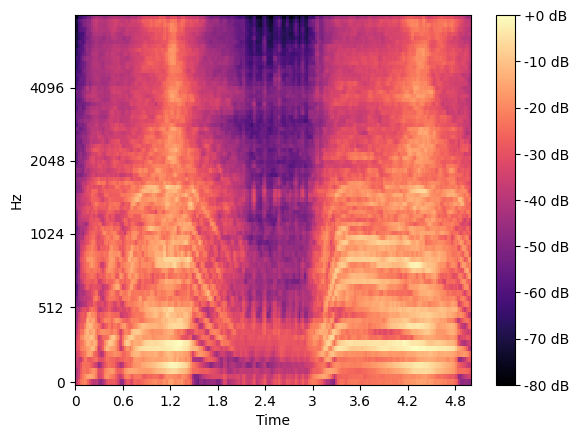

In [6]:
audio_path = os.path.join(ORIGINAL_DIR_PATH, "chainsaw/1-19898-C-41.wav")
assert os.path.isfile(audio_path)
wav, sr = librosa.load(audio_path, sr=None)
plot_mel_spectrogram(wav, sr)


In [ ]:
def plot_mel_spectrogram_comparison(waveform_original, waveform_generated, sr):
    """ rysuje porównanie dwóch mel-spektrogramów (oryginalnego i wygenerowanego) """
    fig, axes = plt.subplots(1,2, figsize=(15,4))
    for i, waveform in enumerate([waveform_original, waveform_generated]):
        S = librosa.feature.melspectrogram(y=waveform, sr=sr, n_mels=80)
        S_dB = librosa.power_to_db(S, ref=np.max)
        
        S_img = librosa.display.specshow(S_dB, x_axis='s',
                                y_axis='mel', sr=sr,
                                fmax=8000, ax=axes[i])
        if i == 0:
            title = "original"
        else:            
            title = "generated"
        axes[i].set(title=title)
    fig.colorbar(S_img, ax=axes, format='%+2.0f dB')
    plt.show()

def load_files(original_audio_path, generated_audio_path):
    assert os.path.isfile(original_audio_path)
    assert os.path.isfile(generated_audio_path)
    wav_o, sr_o = librosa.load(original_audio_path, sr=None)
    wav_g, sr_g = librosa.load(generated_audio_path, sr=None)
    assert sr_o == sr_g
    return wav_o, wav_g, sr_o

chainsaw griffin-lim


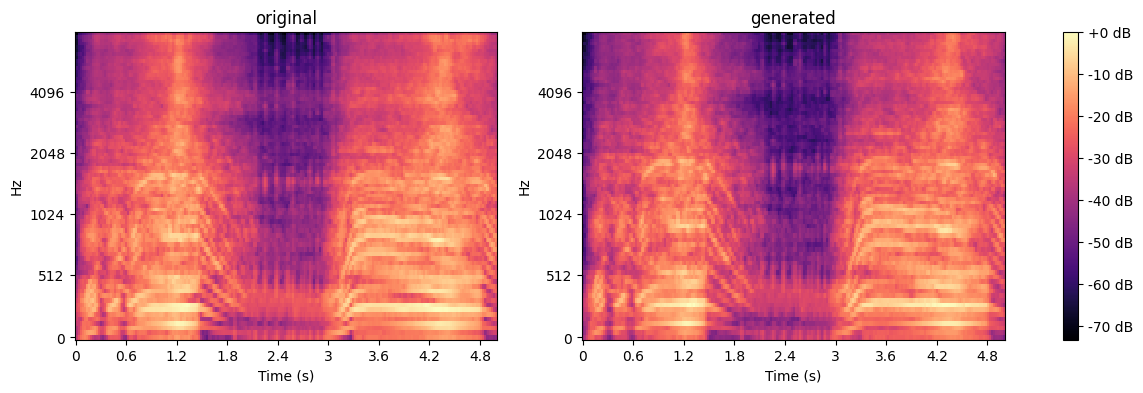

In [9]:
file_path = "chainsaw/1-19898-C-41.wav"
original_audio_path = os.path.join(ORIGINAL_DIR_PATH, file_path)

print("chainsaw griffin-lim")
generated_audio_path = os.path.join(GENERATED_GRIFFIN_LIM_DIR_PATH, file_path)
wav_o, wav_g, sr = load_files(original_audio_path, generated_audio_path)
plot_mel_spectrogram_comparison(waveform_original=wav_o, waveform_generated=wav_g, sr=sr)

## Frechet audio distance

Pliki muszą mieć SR=16kHz, PCM16.

In [ ]:
frechet = FrechetAudioDistance(
    model_name="vggish",
    sample_rate=16000,
    use_pca=False, 
    use_activation=False,
    verbose=False
)

In [ ]:
def calculate_fad(original_dir_path, generated_dir_path):
    """ oblicza FAD dla poszczególnych klas """
    classes = os.listdir(original_dir_path)
    assert classes == os.listdir(generated_dir_path), "classes are not equal"
    fad_scores = []
    for c in classes:
        fad_score = frechet.score(
            os.path.join(original_dir_path, c),
            os.path.join(generated_dir_path, c)
            )
        fad_scores.append(fad_score)
    mean_fad_score = round(np.mean(fad_scores), 2)
    fad_scores = [round(fad_score, 2) for fad_score in fad_scores]
    print(*classes, sep=", ")
    print(*fad_scores, sep=", ")
    print(f"mean FAD score: {round(np.mean(mean_fad_score), 2)}")

In [ ]:
ORIGINAL_DIR_PATH_16K = ""

In [ ]:
print("Griffin-Lim")
calculate_fad(ORIGINAL_DIR_PATH_16K, "")

print("WaveRNN from scratch")
calculate_fad(ORIGINAL_DIR_PATH_16K, "")
print("WaveRNN fine-tuning")
calculate_fad(ORIGINAL_DIR_PATH_16K, "")
print("WaveRNN LJ Speech")
calculate_fad(ORIGINAL_DIR_PATH_16K, "")

print("Hifi-GAN from scratch")
calculate_fad(ORIGINAL_DIR_PATH_16K, "")
print("Hifi-GAN fine-tuning")
calculate_fad(ORIGINAL_DIR_PATH_16K, "")
print("Hifi-GAN LJ Speech")
calculate_fad(ORIGINAL_DIR_PATH_16K, "")

Griffin-Lim
airplane, breathing, brushing_teeth, can_opening, car_horn, cat, chainsaw, chirping_birds, church_bells, clapping, clock_alarm, clock_tick, coughing, cow, crackling_fire, crickets, crow, crying_baby, dog, door_wood_creaks, door_wood_knock, drinking_sipping, engine, fireworks, footsteps, frog, glass_breaking, hand_saw, helicopter, hen, insects, keyboard_typing, laughing, mouse_click, pig, pouring_water, rain, rooster, sea_waves, sheep, siren, sneezing, snoring, thunderstorm, toilet_flush, train, vacuum_cleaner, washing_machine, water_drops, wind;
15.12, 5.49, 14.42, 3.4, 15.54, 4.93, 59.47, 10.3, 22.64, 8.29, 7.89, 5.94, 5.3, 5.52, 8.04, 10.33, 23.0, 5.84, 8.12, 6.64, 5.33, 7.02, 12.3, 6.44, 4.88, 9.19, 7.57, 14.57, 16.23, 8.18, 13.13, 6.54, 16.14, 4.02, 26.21, 6.47, 11.14, 7.6, 11.71, 10.06, 8.69, 6.36, 4.0, 6.98, 15.19, 16.75, 15.35, 21.67, 3.82, 9.38;
mean FAD score: 11.18
WaveRNN from scratch
airplane, breathing, brushing_teeth, can_opening, car_horn, cat, chainsaw, chir

## VISQOL

Pliki muszą mieć SR=48kHz, PCM16. Wyniki uzyskane zgodnie z instrukcją w [repozytorium visqol](https://github.com/google/visqol#build) (linux build).

In [ ]:
def print_mean_visqol_results(results_file_path):
    """ oblicza średnie wyniki VISQOL dla poszczególnych klas """
    results = pd.read_csv(results_file_path)
    results["label"] = results["reference"].apply(lambda row: row.split("/")[-2])
    labels = results["label"].unique()
    labels.sort()
    mean_visqol = []
    for l in labels:
        mean_visqol.append(round(results[results["label"] == l]["moslqo"].mean(), 2))
    print(*labels, sep=", ", end=";\n")
    print(*mean_visqol, sep=", ", end=";\n")
    print(f'mean moslqo: {round(results["moslqo"].mean(), 2)}')

In [53]:
print("Griffin-Lim")
print_mean_visqol_results("visqol_results/visqol_results_griffin-lim.csv")

print("WaveRNN from scratch")
print_mean_visqol_results("visqol_results/visqol_results_wavernn_scratch.csv")
print("WaveRNN fine-tuning")
print_mean_visqol_results("visqol_results/visqol_results_wavernn_fine-tuning.csv")
print("WaveRNN LJ Speech")
print_mean_visqol_results("visqol_results/visqol_results_wavernn_ljspeech.csv")

print("HiFi-GAN from scratch")
print_mean_visqol_results("visqol_results/visqol_results_hifigan_scratch.csv")
print("HiFi-GAN fine-tuning")
print_mean_visqol_results("visqol_results/visqol_results_hifigan_fine-tuning.csv")
print("HiFi-GAN LJ Speech")
print_mean_visqol_results("visqol_results/visqol_results_hifigan_ljspeech.csv")

Griffin-Lim
airplane, breathing, brushing_teeth, can_opening, car_horn, cat, chainsaw, chirping_birds, church_bells, clapping, clock_alarm, clock_tick, coughing, cow, crackling_fire, crickets, crow, crying_baby, dog, door_wood_creaks, door_wood_knock, drinking_sipping, engine, fireworks, footsteps, frog, glass_breaking, hand_saw, helicopter, hen, insects, keyboard_typing, laughing, mouse_click, pig, pouring_water, rain, rooster, sea_waves, sheep, siren, sneezing, snoring, thunderstorm, toilet_flush, train, vacuum_cleaner, washing_machine, water_drops, wind;
3.64, 3.63, 4.07, 3.75, 3.66, 3.85, 3.8, 3.52, 3.89, 4.05, 3.54, 3.77, 3.82, 3.96, 3.86, 3.57, 3.27, 3.61, 3.66, 3.67, 4.1, 4.01, 3.64, 4.18, 4.18, 3.72, 3.74, 3.98, 3.59, 3.94, 3.87, 4.02, 3.93, 4.06, 3.85, 3.56, 3.71, 3.24, 3.85, 3.88, 3.72, 3.88, 3.82, 3.67, 3.78, 3.83, 3.28, 3.48, 3.75, 3.75;
mean moslqo: 3.77
WaveRNN from scratch
airplane, breathing, brushing_teeth, can_opening, car_horn, cat, chainsaw, chirping_birds, church_b

## Zimtohrli

In [ ]:
def calculate_zimtohrli(original_dir_path, generated_dir_path):
    """ oblicza średnie wyniki Zimtohrli dla poszczególnych klas """
    classes = os.listdir(original_dir_path)
    assert classes == os.listdir(generated_dir_path), "classes are not equal"
    results_all = []
    results_classes = []
    for c in classes:
        mos_results = []
        for f in os.listdir(os.path.join(original_dir_path, c)):
            original_file_path = os.path.join(original_dir_path, c, f)
            generated_file_path = os.path.join(generated_dir_path, c, f)
            assert os.path.isfile(generated_file_path), "missing file"
            signal_a, _ = librosa.load(original_file_path, sr=48000, mono=True)
            signal_b, _ = librosa.load(generated_file_path, sr=48000, mono=True)
            mos = mos_from_signals(signal_a, signal_b)
            mos_results.append(mos)
            results_all.append(mos)
        results_classes.append(round(np.mean(mos_results), 2))
    print(*classes, sep=", ", end=";\n")
    print(*results_classes, sep=", ", end=";\n")
    print(f"mean mos = {round(np.mean(results_all), 2)}")

In [17]:
print("Griffin-Lim")
calculate_zimtohrli(ORIGINAL_DIR_PATH, GENERATED_GRIFFIN_LIM_DIR_PATH)

print("WaveRNN from scratch")
calculate_zimtohrli(ORIGINAL_DIR_PATH, GENERATED_WAVERNN_FROM_SCRATCH_DIR_PATH)
print("WaveRNN fine-tuning")
calculate_zimtohrli(ORIGINAL_DIR_PATH, GENERATED_WAVERNN_FINE_TUNING_DIR_PATH)
print("WaveRNN LJ Speech")
calculate_zimtohrli(ORIGINAL_DIR_PATH, GENERATED_WAVERNN_LJSPEECH_DIR_PATH)

print("HiFi-GAN from scratch")
calculate_zimtohrli(ORIGINAL_DIR_PATH, GENERATED_HIFIGAN_FROM_SCRATCH_DIR_PATH)
print("HiFi-GAN fine-tuning")
calculate_zimtohrli(ORIGINAL_DIR_PATH, GENERATED_HIFIGAN_FINE_TUNING_DIR_PATH)
print("HiFi-GAN LJ Speech")
calculate_zimtohrli(ORIGINAL_DIR_PATH, GENERATED_HIFIGAN_LJSPEECH_DIR_PATH)

Griffin-Lim
airplane, breathing, brushing_teeth, can_opening, car_horn, cat, chainsaw, chirping_birds, church_bells, clapping, clock_alarm, clock_tick, coughing, cow, crackling_fire, crickets, crow, crying_baby, dog, door_wood_creaks, door_wood_knock, drinking_sipping, engine, fireworks, footsteps, frog, glass_breaking, hand_saw, helicopter, hen, insects, keyboard_typing, laughing, mouse_click, pig, pouring_water, rain, rooster, sea_waves, sheep, siren, sneezing, snoring, thunderstorm, toilet_flush, train, vacuum_cleaner, washing_machine, water_drops, wind;
3.01, 2.78, 2.74, 3.58, 2.49, 2.48, 2.87, 2.57, 2.28, 3.12, 2.27, 2.96, 2.71, 2.94, 2.87, 2.77, 2.36, 2.03, 2.59, 2.32, 2.9, 3.15, 2.75, 3.51, 3.15, 2.38, 2.63, 2.87, 2.53, 2.67, 2.88, 2.94, 2.51, 3.44, 2.85, 2.41, 3.07, 1.74, 3.0, 2.51, 2.17, 2.94, 2.96, 3.15, 2.64, 3.05, 2.62, 2.57, 3.02, 3.02;
mean mos = 2.76
WaveRNN from scratch
airplane, breathing, brushing_teeth, can_opening, car_horn, cat, chainsaw, chirping_birds, church_bel

## wykresy

In [ ]:
def plot_visqol_zimtohrli(visqol_values, zimtohrli_values, labels):
    """ rysuje wykres z wynikami VISQOL i Zimtohrli """

    y = range(len(labels))

    plt.figure(figsize=(4, len(labels)/4))
    point_size = 15
    plt.scatter(
        visqol_values,
        y,
        marker="o",
        s=point_size,
        label="VISQOL"
    )

    plt.scatter(
        zimtohrli_values,
        y,
        marker="s",
        s=point_size,
        label="Zimtohrli"
    )

    plt.yticks(y, labels)
    plt.xticks(range(1, 6))
    plt.xlim(0.9, 5.1)

    plt.xlabel("Wartość")
    plt.ylabel("Klasa")
    plt.grid(axis="both", linestyle="--", alpha=0.5)
    plt.legend(bbox_to_anchor=(1, 1), loc="center left")

    plt.show()

def plot_visqol_zimtohrli_2(visqol_values_wavernn, zimtohrli_values_wavernn, visqol_values_hifigan, zimtohrli_values_hifigan, labels):
    """ rysuje wykres z wynikami VISQOL i Zimtohrli dla dwóch modeli """

    y = range(len(labels))

    plt.figure(figsize=(7, len(labels)/4))
    point_size = 15
    plt.scatter(
        visqol_values_wavernn,
        y,
        marker="o",
        facecolors="C0",
        s=point_size,
        label="VISQOL wavernn"
    )

    plt.scatter(
        zimtohrli_values_wavernn,
        y,
        marker="s",
        facecolors="C1",
        s=point_size,
        label="Zimtohrli wavernn"
    )

    plt.scatter(
        visqol_values_hifigan,
        y,
        marker="o",        
        facecolors="none",
        edgecolors="C0",
        s=point_size,
        label="VISQOL hifigan"
    )

    plt.scatter(
        zimtohrli_values_hifigan,
        y,
        marker="s",
        facecolors="none",
        edgecolors="C1",
        s=point_size,
        label="Zimtohrli hifigan"
    )

    plt.yticks(y, labels)
    plt.xticks(range(1, 6))
    plt.xlim(0.9, 5.1)

    plt.xlabel("Wartość")
    plt.ylabel("Klasa")
    plt.grid(axis="both", linestyle="--", alpha=0.5)
    plt.legend(bbox_to_anchor=(1, 1), loc="center left")

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_zcr(zcr_values, labels):
    """ rysuje wykres z wynikami ZCR """

    y = range(len(labels))

    plt.figure(figsize=(4, len(labels)/4))
    point_size = 15
    plt.scatter(
        zcr_values,
        y,
        marker="o",
        s=point_size,
        label=r"$\Delta$ ZCR"
    )

    plt.yticks(y, labels)
    plt.xlim(-0.5, 0.5)

    plt.xlabel("Wartość")
    plt.ylabel("Klasa")
    plt.grid(axis="both", linestyle="--", alpha=0.5)
    plt.legend(bbox_to_anchor=(1, 1), loc="center left")

    plt.show()

def plot_zcr_2(zcr_values_wavernn, zcr_values_hifigan, labels):
    """ rysuje wykres z wynikami ZCR dla dwóch modeli"""

    y = range(len(labels))

    plt.figure(figsize=(4, len(labels)/4))
    point_size = 15
    plt.scatter(
        zcr_values_wavernn,
        y,
        marker="o",
        s=point_size,
        label=r"$\Delta$ ZCR WaveRNN"
    )

    plt.scatter(
        zcr_values_hifigan,
        y,
        marker="o",
        s=point_size,
        label=r"$\Delta$ ZCR HiFi-GAN"
    )

    plt.yticks(y, labels)
    plt.xlim(-0.5, 0.5)

    plt.xlabel("Wartość")
    plt.ylabel("Klasa")
    plt.grid(axis="both", linestyle="--", alpha=0.5)
    plt.legend(bbox_to_anchor=(1, 1), loc="center left")

    plt.show()

In [ ]:
def plot_spectral_flatness(sf_values, labels):
    """ rysuje wykres z wynikami spectral flatness """

    y = range(len(labels))

    plt.figure(figsize=(4, len(labels)/4))
    point_size = 15
    plt.scatter(
        sf_values,
        y,
        marker="o",
        s=point_size,
        label=r"$\Delta$ Spectral flatness"
    )

    plt.yticks(y, labels)
    plt.xlim(-0.5, 0.5)

    plt.xlabel("Wartość")
    plt.ylabel("Klasa")
    plt.grid(axis="both", linestyle="--", alpha=0.5)
    plt.legend(bbox_to_anchor=(1, 1), loc="center left")

    plt.show()

def plot_spectral_flatness_2(sf_values_wavernn, sf_values_hifigan, labels):
    """ rysuje wykres z wynikami spectral flatness dla dwóch modeli """

    y = range(len(labels))

    plt.figure(figsize=(4, len(labels)/4))
    point_size = 15
    plt.scatter(
        sf_values_wavernn,
        y,
        marker="o",
        s=point_size,
        label=r"$\Delta$ Spectral flatness WaveRNN"
    )

    plt.scatter(
        sf_values_hifigan,
        y,
        marker="o",
        s=point_size,
        label=r"$\Delta$ Spectral flatness HiFi-GAN"
    )

    plt.yticks(y, labels)
    plt.xlim(-0.5, 0.5)

    plt.xlabel("Wartość")
    plt.ylabel("Klasa")
    plt.grid(axis="both", linestyle="--", alpha=0.5)
    plt.legend(bbox_to_anchor=(1, 1), loc="center left")

    plt.show()

In [ ]:
# wyniki
labels = ["airplane", "breathing", "brushing_teeth", "can_opening", "car_horn", "cat", "chainsaw", "chirping_birds", "church_bells", "clapping", "clock_alarm", "clock_tick", "coughing", "cow", "crackling_fire", "crickets", "crow", "crying_baby", "dog", "door_wood_creaks", "door_wood_knock", "drinking_sipping", "engine", "fireworks", "footsteps", "frog", "glass_breaking", "hand_saw", "helicopter", "hen", "insects", "keyboard_typing", "laughing", "mouse_click", "pig", "pouring_water", "rain", "rooster", "sea_waves", "sheep", "siren", "sneezing", "snoring", "thunderstorm", "toilet_flush", "train", "vacuum_cleaner", "washing_machine", "water_drops", "wind"]

# visqol zimtohrli
griffin_lim_visqol = [3.64, 3.63, 4.07, 3.75, 3.66, 3.85, 3.8, 3.52, 3.89, 4.05, 3.54, 3.77, 3.82, 3.96, 3.86, 3.57, 3.27, 3.61, 3.66, 3.67, 4.1, 4.01, 3.64, 4.18, 4.18, 3.72, 3.74, 3.98, 3.59, 3.94, 3.87, 4.02, 3.93, 4.06, 3.85, 3.56, 3.71, 3.24, 3.85, 3.88, 3.72, 3.88, 3.82, 3.67, 3.78, 3.83, 3.28, 3.48, 3.75, 3.75]
griffin_lim_zimtohrli = [3.01, 2.78, 2.74, 3.58, 2.49, 2.48, 2.87, 2.57, 2.28, 3.12, 2.27, 2.96, 2.71, 2.94, 2.87, 2.77, 2.36, 2.03, 2.59, 2.32, 2.9, 3.15, 2.75, 3.51, 3.15, 2.38, 2.63, 2.87, 2.53, 2.67, 2.88, 2.94, 2.51, 3.44, 2.85, 2.41, 3.07, 1.74, 3.0, 2.51, 2.17, 2.94, 2.96, 3.15, 2.64, 3.05, 2.62, 2.57, 3.02, 3.02]

wavernn_esc50_visqol = [2.85, 3.02, 3.11, 3.16, 3.15, 3.11, 3.05, 3.05, 2.91, 3.13, 3.27, 3.29, 3.16, 3.3, 3.25, 3.0, 2.99, 2.91, 3.08, 3.48, 2.96, 3.51, 2.66, 3.86, 3.21, 2.75, 3.01, 3.03, 2.99, 3.2, 3.08, 3.07, 3.27, 3.47, 2.8, 2.95, 3.49, 3.05, 3.01, 3.46, 3.2, 3.26, 3.29, 3.26, 3.2, 2.87, 3.39, 3.34, 3.1, 3.16]
wavernn_esc50_zimtohrli = [2.02, 1.93, 1.81, 2.04, 2.0, 2.0, 2.16, 1.97, 1.91, 1.97, 1.71, 1.77, 1.81, 1.94, 1.79, 1.73, 1.97, 1.6, 1.67, 1.79, 1.58, 1.74, 2.09, 2.03, 1.64, 1.62, 1.92, 1.73, 2.1, 1.86, 2.03, 1.42, 1.88, 2.07, 2.05, 1.62, 2.45, 1.55, 2.3, 1.99, 1.68, 2.13, 2.27, 1.75, 2.04, 2.3, 2.22, 2.18, 2.13, 1.98]
wavernn_fine_tuning_visqol = [2.63, 3.44, 4.01, 4.07, 3.32, 4.0, 3.52, 3.97, 3.02, 3.41, 3.84, 3.93, 3.75, 3.74, 4.01, 3.97, 3.84, 3.84, 3.45, 3.81, 3.08, 4.04, 3.12, 4.02, 3.93, 3.7, 3.89, 3.56, 3.36, 3.94, 3.63, 3.75, 3.7, 3.96, 3.5, 3.49, 3.9, 3.6, 3.33, 4.05, 3.0, 3.82, 3.95, 3.31, 3.37, 3.05, 3.14, 3.51, 3.61, 3.59]
wavernn_fine_tuning_zimtohrli = [2.29, 2.62, 2.55, 3.3, 2.48, 2.84, 2.62, 2.75, 2.3, 2.61, 2.53, 2.59, 2.81, 2.7, 2.4, 2.5, 2.55, 2.53, 2.0, 2.71, 2.06, 2.46, 1.77, 2.74, 2.83, 2.22, 3.02, 2.35, 2.14, 2.75, 2.93, 2.61, 2.34, 2.54, 2.51, 2.76, 2.93, 2.45, 2.56, 2.58, 2.04, 2.86, 2.67, 2.08, 2.51, 2.23, 2.67, 2.63, 2.98, 2.41]
wavernn_ljspeech_visqol = [3.08, 4.1, 4.46, 4.23, 4.0, 4.14, 4.2, 4.3, 3.8, 3.92, 4.02, 4.02, 4.04, 4.03, 3.84, 4.32, 4.24, 3.98, 3.79, 4.02, 3.28, 4.16, 3.6, 4.23, 4.12, 3.99, 4.07, 4.24, 4.31, 4.12, 4.22, 4.33, 4.11, 4.22, 4.19, 4.05, 4.18, 3.8, 4.03, 4.27, 3.37, 4.05, 4.16, 3.62, 3.98, 3.97, 4.18, 4.17, 4.21, 4.06]
wavernn_ljspeech_zimtohrli = [2.6, 3.3, 3.06, 3.69, 3.09, 3.42, 3.06, 3.24, 2.95, 2.81, 3.0, 3.34, 3.05, 3.08, 2.67, 2.99, 3.22, 2.82, 2.91, 3.19, 2.55, 3.11, 2.48, 3.24, 3.2, 2.61, 3.31, 3.0, 2.75, 3.37, 3.4, 2.75, 3.03, 3.46, 3.04, 2.86, 3.18, 2.71, 2.97, 3.05, 2.35, 3.68, 2.97, 2.65, 2.92, 2.79, 3.14, 3.05, 3.73, 2.79]

hifigan_esc50_visqol = [3.27, 3.01, 3.38, 3.36, 3.14, 3.52, 3.02, 3.32, 3.08, 2.92, 3.32, 3.12, 3.1, 3.42, 2.84, 2.87, 3.14, 3.0, 3.22, 3.51, 3.45, 3.5, 2.54, 3.91, 2.72, 2.91, 3.11, 2.79, 2.59, 2.76, 2.62, 2.94, 3.14, 3.49, 2.79, 3.33, 3.44, 3.06, 2.39, 3.06, 2.7, 3.31, 3.16, 3.24, 2.81, 2.75, 3.07, 3.06, 3.06, 3.16]
hifigan_esc50_zimtohrli = [2.85, 2.24, 2.05, 2.91, 2.55, 2.8, 2.38, 2.7, 2.43, 2.15, 2.02, 2.76, 2.44, 2.64, 1.96, 2.57, 2.49, 2.07, 2.25, 2.49, 2.0, 2.44, 2.13, 2.79, 2.01, 2.11, 2.42, 1.96, 1.99, 2.18, 2.58, 1.73, 2.28, 3.01, 2.21, 2.24, 2.91, 1.96, 2.51, 2.47, 2.27, 2.6, 3.01, 2.48, 2.3, 2.57, 2.99, 2.74, 3.15, 2.57]
hifigan_fine_tuning_visqol = [3.86, 4.21, 4.42, 3.89, 4.1, 4.13, 4.39, 3.71, 4.35, 4.32, 3.5, 3.91, 4.17, 4.27, 4.24, 3.34, 3.94, 3.92, 3.89, 3.92, 3.89, 4.16, 3.88, 4.31, 4.17, 4.02, 4.07, 4.38, 4.14, 3.87, 4.34, 4.12, 4.33, 4.11, 4.51, 3.76, 4.23, 3.96, 4.33, 4.19, 4.09, 4.16, 4.22, 3.93, 4.27, 4.31, 3.96, 4.26, 3.7, 4.43]
hifigan_fine_tuning_zimtohrli = [3.87, 3.89, 3.96, 3.96, 3.84, 3.86, 4.1, 3.85, 3.96, 3.9, 3.32, 3.85, 3.84, 4.2, 3.81, 3.26, 3.83, 3.6, 3.81, 3.27, 3.76, 3.81, 3.66, 3.94, 3.8, 3.7, 3.62, 3.98, 3.53, 3.71, 4.14, 3.59, 3.94, 3.76, 3.99, 3.05, 3.84, 3.26, 4.05, 3.91, 3.66, 4.07, 3.91, 3.75, 3.79, 3.98, 3.81, 3.92, 3.78, 3.92]
hifigan_ljspeech_visqol = [3.27, 3.19, 3.18, 3.43, 3.25, 2.79, 3.16, 3.25, 3.38, 3.09, 3.06, 3.12, 3.22, 3.59, 2.8, 2.69, 3.1, 3.06, 3.29, 3.61, 3.43, 3.57, 2.68, 3.97, 2.72, 3.19, 3.01, 2.85, 3.2, 2.82, 2.59, 2.81, 3.29, 3.43, 3.1, 2.85, 3.85, 3.05, 2.53, 3.33, 3.03, 3.41, 3.05, 3.23, 3.02, 3.23, 3.24, 3.48, 3.0, 3.43]
hifigan_ljspeech_zimtohrli = [2.57, 2.28, 1.97, 2.82, 2.34, 3.03, 2.61, 2.88, 2.41, 2.0, 2.69, 2.71, 2.5, 2.52, 1.93, 2.36, 2.18, 2.11, 2.08, 2.76, 2.23, 2.57, 2.12, 2.97, 2.23, 2.18, 2.1, 1.78, 2.36, 2.32, 2.56, 1.7, 2.1, 2.95, 2.38, 2.31, 2.98, 2.31, 2.36, 2.43, 2.13, 2.49, 2.97, 2.45, 2.2, 2.54, 3.03, 2.77, 3.13, 2.66]

# ZCR
griffin_lim_zcr = [-0.02, -0.02, -0.04, -0.05, -0.03, -0.03, -0.02, -0.05, -0.02, -0.03, 0.05, -0.01, -0.02, -0.01, -0.02, 0.12, -0.05, -0.04, -0.01, -0.05, -0.01, -0.02, -0.02, -0.02, -0.02, -0.04, -0.03, -0.03, 0.0, -0.03, -0.02, -0.03, -0.02, -0.01, -0.02, -0.05, -0.05, -0.04, -0.02, -0.03, -0.01, -0.02, -0.02, -0.01, -0.04, -0.01, -0.06, -0.04, -0.02, -0.02]

wavernn_esc50_zcr = [-0.21, -0.1, -0.14, -0.04, -0.12, -0.01, -0.19, -0.12, -0.14, -0.18, 0.07, -0.09, -0.09, -0.09, -0.04, 0.07, -0.14, -0.14, -0.11, -0.11, -0.14, -0.06, -0.07, -0.15, -0.02, -0.14, -0.01, -0.08, -0.36, -0.09, -0.13, -0.13, -0.11, -0.1, -0.16, -0.01, -0.16, -0.08, -0.08, -0.15, -0.12, -0.05, 0.01, -0.09, -0.15, -0.15, -0.09, -0.15, -0.06, -0.07]
wavernn_fine_tuning_zcr = [-0.01, -0.01, -0.0, -0.05, 0.0, 0.02, 0.02, 0.01, 0.02, 0.01, 0.09, -0.01, -0.04, -0.01, -0.06, -0.02, -0.02, -0.02, 0.0, -0.02, -0.05, -0.06, -0.06, 0.0, 0.01, -0.04, -0.02, -0.01, 0.01, -0.01, -0.01, -0.04, -0.02, -0.05, 0.0, -0.02, 0.03, -0.01, 0.01, -0.01, -0.03, -0.01, -0.04, -0.01, 0.03, -0.02, 0.08, 0.01, 0.02, -0.01]
wavernn_ljspeech_zcr = [-0.02, -0.02, -0.01, -0.08, 0.0, -0.0, 0.01, -0.0, 0.01, 0.02, 0.09, -0.02, -0.05, -0.03, -0.08, -0.05, -0.01, -0.03, -0.02, -0.04, -0.06, -0.06, -0.07, -0.02, -0.01, -0.07, -0.04, -0.02, -0.01, -0.03, -0.01, -0.07, -0.02, -0.08, -0.0, -0.04, 0.01, 0.0, 0.01, -0.02, -0.02, -0.02, -0.06, -0.02, 0.03, -0.01, 0.08, 0.01, -0.02, -0.02]

hifigan_esc50_zcr = [0.03, 0.03, 0.06, 0.1, 0.04, 0.05, 0.07, 0.11, 0.03, 0.04, 0.29, -0.01, 0.04, 0.03, 0.04, 0.35, 0.05, 0.0, 0.02, 0.01, -0.01, 0.05, 0.01, 0.0, 0.07, 0.03, 0.13, 0.06, 0.16, 0.04, 0.07, 0.07, 0.04, 0.04, 0.04, 0.14, 0.08, 0.06, 0.05, 0.02, 0.01, 0.12, 0.06, 0.01, 0.07, 0.01, 0.14, 0.06, 0.03, 0.03]
hifigan_fine_tuning_zcr = [-0.02, -0.01, -0.0, 0.03, -0.0, 0.02, -0.01, 0.02, 0.0, -0.01, 0.17, -0.0, -0.01, 0.0, -0.01, 0.16, -0.01, -0.02, 0.0, -0.02, -0.01, 0.02, -0.0, -0.01, 0.01, -0.01, 0.02, 0.0, 0.02, 0.01, -0.0, 0.01, 0.02, 0.01, -0.01, 0.03, -0.03, 0.01, -0.01, -0.01, -0.0, 0.05, 0.0, 0.0, -0.01, -0.01, 0.01, 0.0, 0.02, -0.0]
hifigan_ljspeech_zcr = [0.02, 0.02, 0.08, -0.01, 0.03, 0.05, 0.07, 0.04, 0.04, 0.06, 0.17, 0.02, -0.0, 0.01, 0.05, 0.16, 0.04, -0.0, 0.01, -0.03, -0.02, -0.01, -0.02, -0.01, 0.09, -0.0, 0.05, 0.05, 0.04, 0.02, 0.07, 0.01, 0.03, -0.01, 0.04, 0.06, 0.05, 0.03, 0.04, 0.01, 0.0, 0.06, 0.03, 0.01, 0.08, 0.0, 0.12, 0.04, 0.02, 0.0]

# spectral flatness
griffin_lim_sf = [-0.05, -0.01, -0.15, -0.08, -0.01, -0.04, -0.08, -0.1, -0.01, -0.1, -0.04, -0.01, -0.02, -0.02, -0.07, -0.06, -0.11, -0.03, -0.01, -0.04, 0.0, -0.0, -0.01, -0.03, -0.1, -0.03, -0.08, -0.09, -0.06, -0.03, -0.06, -0.09, -0.02, -0.03, -0.04, -0.07, -0.33, -0.01, -0.07, -0.02, -0.0, -0.07, -0.05, -0.01, -0.13, -0.02, -0.1, -0.07, -0.03, -0.02]

wavernn_esc50_sf = [-0.09, -0.05, -0.07, -0.04, -0.11, -0.03, -0.18, -0.1, -0.08, -0.18, -0.13, -0.02, -0.09, -0.02, -0.0, -0.13, -0.13, -0.1, -0.02, -0.06, -0.06, 0.0, -0.05, -0.03, -0.01, -0.04, -0.07, -0.08, -0.21, -0.04, -0.11, -0.02, -0.08, 0.06, -0.09, -0.0, -0.1, -0.07, -0.13, -0.03, -0.06, -0.08, -0.02, -0.03, -0.15, -0.13, -0.23, -0.22, -0.04, -0.08]
wavernn_fine_tuning_sf = [-0.06, -0.04, -0.08, -0.1, -0.06, -0.01, -0.03, -0.04, -0.03, -0.07, -0.09, -0.02, -0.08, -0.03, -0.05, -0.05, -0.05, -0.05, -0.02, -0.04, -0.08, -0.05, -0.07, -0.02, -0.01, -0.06, -0.14, -0.06, -0.06, -0.03, -0.05, -0.05, -0.06, 0.03, -0.03, -0.02, -0.06, -0.08, -0.01, -0.03, -0.03, -0.09, -0.06, -0.02, -0.05, -0.04, -0.08, -0.06, -0.02, -0.04]
wavernn_ljspeech_sf = [-0.03, -0.02, -0.05, -0.09, -0.03, -0.02, -0.01, -0.03, -0.02, -0.02, -0.05, -0.02, -0.07, -0.03, -0.05, -0.03, -0.03, -0.04, -0.02, -0.05, -0.06, -0.02, -0.04, -0.02, -0.01, -0.07, -0.09, -0.04, -0.04, -0.03, -0.03, -0.05, -0.03, 0.05, -0.02, -0.03, -0.04, -0.04, -0.01, -0.02, -0.02, -0.07, -0.07, -0.02, -0.01, -0.02, -0.03, -0.03, -0.02, -0.02]

hifigan_esc50_sf = [0.01, 0.01, 0.04, 0.04, 0.0, 0.02, 0.04, 0.04, -0.0, 0.02, -0.02, 0.0, 0.01, 0.02, 0.03, -0.03, 0.0, -0.01, 0.0, -0.03, -0.0, 0.09, 0.01, -0.0, 0.07, 0.01, 0.01, 0.05, 0.05, 0.01, 0.04, 0.05, 0.02, 0.14, 0.0, 0.05, 0.04, -0.0, 0.04, 0.0, -0.0, 0.05, 0.04, 0.0, 0.05, -0.01, 0.0, 0.01, 0.01, -0.01]
hifigan_fine_tuning_sf = [-0.03, 0.0, -0.04, 0.02, -0.01, 0.01, -0.02, 0.01, -0.0, -0.03, -0.01, -0.0, -0.0, -0.0, -0.01, -0.03, -0.03, -0.01, -0.0, -0.02, 0.0, 0.08, 0.0, -0.01, 0.01, -0.0, -0.02, -0.01, -0.02, 0.0, -0.01, 0.01, 0.02, 0.13, -0.01, 0.04, -0.11, 0.0, -0.01, -0.0, -0.0, 0.02, -0.0, -0.0, -0.03, -0.01, -0.08, -0.03, 0.01, -0.01]
hifigan_ljspeech_sf = [0.02, 0.01, 0.1, 0.03, 0.01, 0.03, 0.04, 0.07, 0.0, 0.07, 0.01, 0.01, 0.01, 0.01, 0.05, 0.01, 0.02, 0.01, 0.0, -0.0, -0.0, 0.08, 0.01, 0.0, 0.09, 0.0, 0.05, 0.05, 0.02, 0.01, 0.04, 0.05, 0.02, 0.14, 0.01, 0.07, 0.04, 0.02, 0.04, 0.0, -0.0, 0.04, 0.03, 0.0, 0.07, 0.0, 0.03, 0.01, 0.02, 0.01]


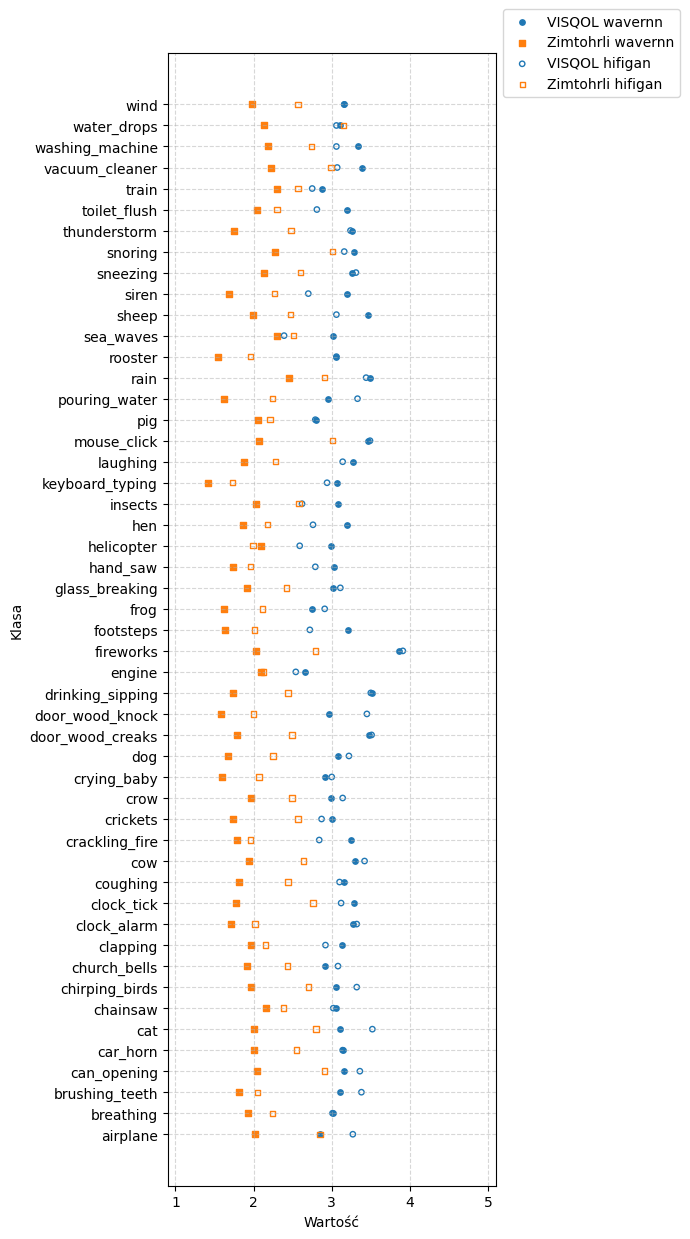

In [ ]:
# griffin-lim
# plot_visqol_zimtohrli(griffin_lim_visqol, griffin_lim_zimtohrli, labels)
# plot_zcr(griffin_lim_zcr, labels)
# plot_spectral_flatness(griffin_lim_sf, labels)

# ljspeech
# plot_visqol_zimtohrli_2(wavernn_ljspeech_visqol, wavernn_ljspeech_zimtohrli, hifigan_ljspeech_visqol, hifigan_ljspeech_zimtohrli, labels)
# plot_zcr_2(wavernn_ljspeech_zcr, hifigan_ljspeech_zcr, labels)
# plot_spectral_flatness_2(wavernn_ljspeech_sf, hifigan_ljspeech_sf, labels)

# esc-50
plot_visqol_zimtohrli_2(wavernn_esc50_visqol, wavernn_esc50_zimtohrli, hifigan_esc50_visqol, hifigan_esc50_zimtohrli, labels)
# plot_zcr_2(wavernn_esc50_zcr, hifigan_esc50_zcr, labels)
# plot_spectral_flatness_2(wavernn_esc50_sf, hifigan_esc50_sf, labels)

# fine-tuning
# plot_visqol_zimtohrli_2(wavernn_fine_tuning_visqol, wavernn_fine_tuning_zimtohrli, hifigan_fine_tuning_visqol, hifigan_fine_tuning_zimtohrli, labels)
# plot_zcr_2(wavernn_fine_tuning_zcr, hifigan_fine_tuning_zcr, labels)
# plot_spectral_flatness_2(wavernn_fine_tuning_sf, hifigan_fine_tuning_sf, labels)
